Proszę zbudować model służący do analizy sentymentu tweetów zebranych w zbiorze
danych:
https://www.kaggle.com/datasets/austinreese/trump-tweets
(podobnymi metodami jak przedstawione na zajęciach). Następnie dla zbudowanego
modelu proszę przeprowadzić analizę SHAP i przeprowadzić dyskusję uzyskanych
wyników.

## Plan

### 1. Preprocessing
- usuniecie linkow, mentions

### 2. Automatyczne etykietowanie
- VADER

### 3. Reprezentacja tekstu
- TF-IDF
- SBERT / embeddings

### 4. Budowa modeli
Klasyfikacja sentymentu:
- positive
- neutral
- negative

### 5. SHAP
- interpretacja predykcji
- wpływ słów / cech

### 6. Analiza wyników
- porównanie modeli
- interpretowalność
- błędy i ograniczenia

In [4]:
from src.dataset import TrumpTweetDataset
import torch
from torch.utils.data import DataLoader, random_split

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {device}")

dataset = TrumpTweetDataset(threshold=0.25,overwrite=False,device=device)

Using device: cuda
Loading from files.


In [5]:
print(dataset.df["label"].value_counts())

label
2    23272
1    10919
0     9161
Name: count, dtype: int64


Explained variance ratio: [0.16584282 0.12012389]


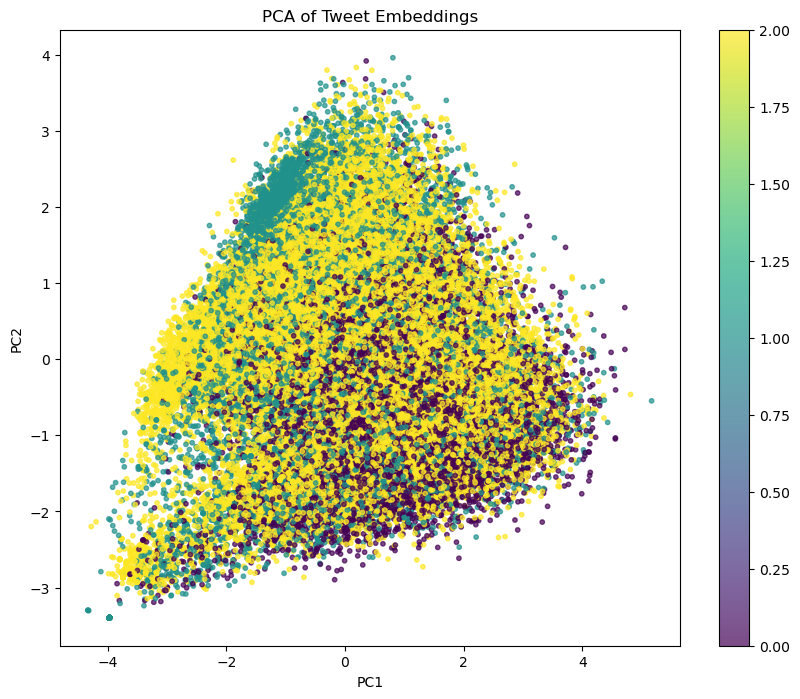

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

embeddings = dataset.embeddings.numpy()
labels = dataset.labels.numpy()

embeddings_2d = pca.fit_transform(embeddings)

print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=labels,
    s=10,
    alpha=0.7,
)

plt.title(
    "PCA of Tweet Embeddings"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(scatter)

plt.show()